# Collect_results
1. Models:
    1. baseline
    2. gaussian blur
    3. haar wavelet
    4. frozen unet: using retangular mask, preserved raio from 0.1-0.5
        - use pretrain and frozen during hidden pipeline training
2. eval attacks:
    1. mean
    2. telea
    3. navier
    4. shiftmap
    5. PDE based diffusion
3. masks:
    1. retangular mask for sweep, preserved ratio from  0.1 to 0.9
    2. sparse mask, preserved ratio: 0.1, 0.3
        - optimized mask, using ps and nlpe, 2 parameter set:
            - a. diffusion=150, nlpe=100 
            - b. diffusion=300, nlpe=200 
        - random mask, use seed=42 to generated.
4. results table:
    1. retangular mask: 4 models, 5 attacks, using sweep
    2. sparse mask: 4 models, 4 attacks(without shiftmap since it's pixel-wised mask)
5. key measure indicators:
    - attacked images:
        1. BER, decoded message error rate, lower means weaker attack
        2. SSIM and PSNR, image quality, higher means better quality
    - models:
        1. use run validated results's data



In [1]:
output_folder_path = "/home/keen/HiDDeN/output"
#path validate trained model's output
trained_baseline_info_path = "/home/keen/HiDDeN/evaluation_3k_baseline_results.json"
trained_frozen_unet_info_path = "/home/keen/HiDDeN/evaluation_3k_frozen_pretrained_unet_eval_aligned_results.json"
trained_gaussian_blur_info_path = "/home/keen/HiDDeN/evaluation_3k_gaussian_blur_results.json"
trained_haar_wavelet_info_path = "/home/keen/HiDDeN/evaluation_3k_haar_wavelet_results.json"

#path, retangular mask, sweep results
# removal ratio = 0, original
clean_sweep_baseline_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_baseline_S_42.json"
clean_sweep_frozen_unet_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_frozen_pretrained_unet_eval_aligned_S_42.json"
clean_sweep_gaussian_blur_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_gaussian_blur_S_42.json"
clean_sweep_haar_wavelet_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_haar_wavelet_S_42.json"
#sweep result:
sweep_baseline_A_mean_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_mean_R_0.10_0.90_S_42.json"
sweep_baseline_A_diffusion_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_diffusion_R_0.10_0.90_S_42.json"
sweep_baseline_A_telea_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_telea_R_0.10_0.90_S_42.json"
sweep_baseline_A_shiftmap_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_shiftmap_R_0.10_0.90_S_42.json"
sweep_baseline_A_navier_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_navier_R_0.10_0.90_S_42.json"
# optimized mask result:4 set parameters, 4 models, 5 attacks, diffusion, mean, telea, shiftmap, navier
# here is just illustration, other model and attack have similiar format
# diff 150, nlpe 100, density 10%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.1__val_ps_nlpe_masks_density_100__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.1__val_ps_nlpe_masks_density_100__seed_42/images"
# diff 150, nlpe 100, density 30%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.3__val_ps_nlpe_masks_density_300__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.3__val_ps_nlpe_masks_density_300__seed_42/images"
# diff 300, nlpe 200, density 10%
opt_mask_baseline_A_diffusion_diff_300_nlpe_200_den_100_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.1__val_ps_nlpe_masks_density_100__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.1__val_ps_nlpe_masks_density_100__seed_42/images"
# diff 300, nlpe 200, density 30%
opt_mask_baseline_A_diffusion_diff_300_nlpe_200_den_100_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.3__val_ps_nlpe_masks_density_300__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_300_nlpe_200_den_100_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.3__val_ps_nlpe_masks_density_300__seed_42/images"

# sparse random mask result:2 set parameters, 4 models, 4 attacks, diffusion, mean, telea, navier
# here is just illustration, other model and attack have similiar format
# density 10%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_result_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.1_seed_42__val_random_masks_density_100__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_first_10_images_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.1_seed_42__val_random_masks_density_100__seed_42/images"
# density 30%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_result_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.3_seed_42__val_random_masks_density_300__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_first_10_images_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.3_seed_42__val_random_masks_density_300__seed_42/images"

In [2]:
# model names:
baseline_run = "3k_baseline 2026.05.13--12-17-40"
unet_run = "3k_frozen_pretrained_unet_eval_aligned 2026.08.24--04-07-29"
gaussian_blur_run = "3k_gaussian_blur 2026.05.26--18-42-22"
haar_wavelet_run = "3k_haar_wavelet 2026.05.26--12-12-55"

In [3]:
# commands: 
# get models info
"""
python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_baseline 2026.05.13--12-17-40"

python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_frozen_pretrained_unet_eval_aligned 2026.08.24--04-07-29"

python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_gaussian_blur 2026.05.26--18-42-22"

python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_haar_wavelet 2026.05.26--12-12-55"
"""

'\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_baseline 2026.05.13--12-17-40"\n\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_frozen_pretrained_unet_eval_aligned 2026.08.24--04-07-29"\n\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_gaussian_blur 2026.05.26--18-42-22"\n\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_haar_wavelet 2026.05.26--12-12-55"\n'

In [4]:
# scripts for sweep summary tables:
# python collect_results.py

# scripts for opt_mask and sparse_random_mask
# python collect_sparse_results.py

# plots
### sweep results visualization

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


csv_path = Path("/home/keen/HiDDeN/output/csv/rectangular_mask_results.csv")

df = pd.read_csv(csv_path)

df.head()

,model,attack,removal_ratio,PSNR,SSIM,BER
0,Baseline,mean,0.1,24.082294,0.866239,0.028556
1,Baseline,mean,0.2,21.282916,0.792153,0.030111
2,Baseline,mean,0.3,19.511084,0.720505,0.034889
3,Baseline,mean,0.4,18.208468,0.651576,0.042889
4,Baseline,mean,0.5,17.158511,0.585099,0.060000


In [6]:
print(df.columns)

print("\nModels:")
print(df["model"].unique())

print("\nAttacks:")
print(df["attack"].unique())

Index(['model', 'attack', 'removal_ratio', 'PSNR', 'SSIM', 'BER'], dtype='object')

Models:
['Baseline' 'Gaussian Blur' 'Haar Wavelet' 'Frozen UNet']

Attacks:
['mean' 'telea' 'navier' 'shiftmap' 'diffusion']


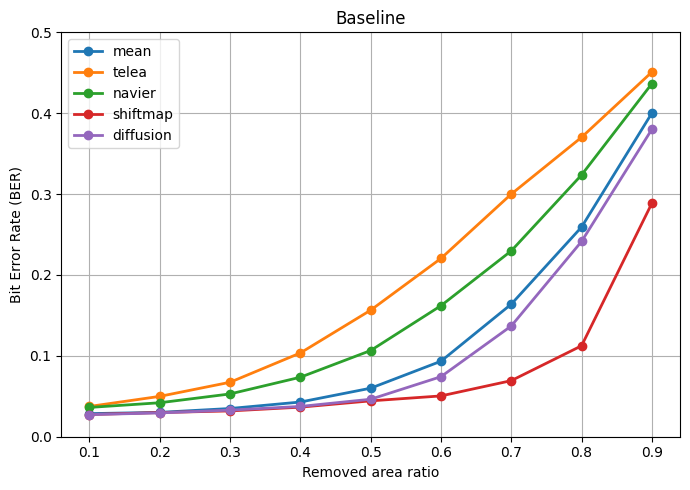

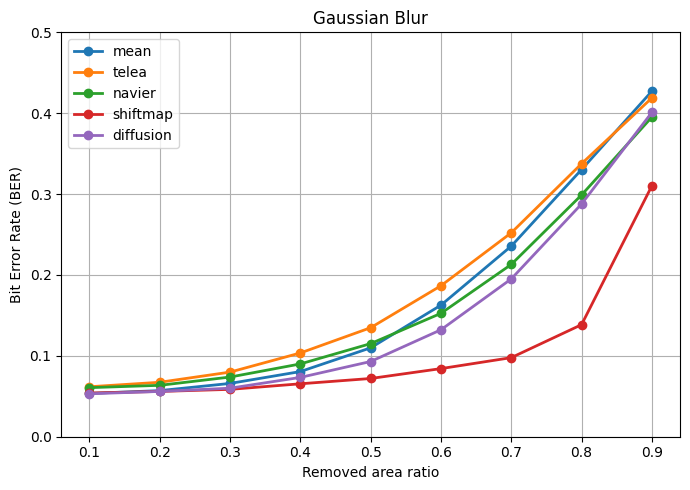

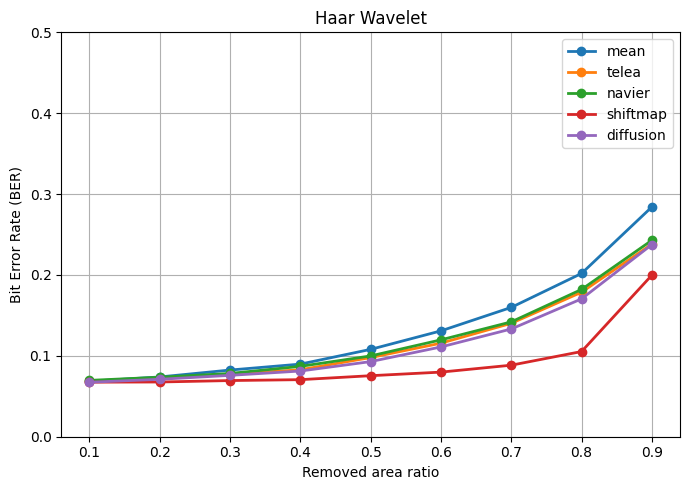

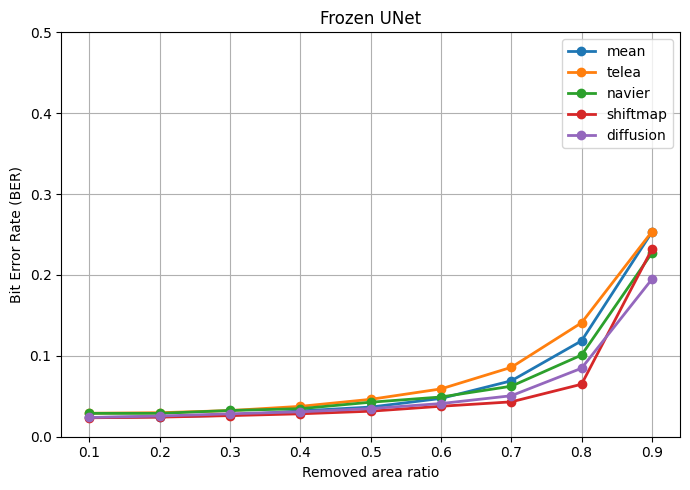

In [7]:
models = df["model"].unique()

fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(exist_ok=True)


for model in models:
    
    plt.figure(figsize=(7,5))
    
    model_df = df[df["model"] == model]
    
    for attack in model_df["attack"].unique():
        
        attack_df = (
            model_df[model_df["attack"] == attack]
            .sort_values("removal_ratio")
        )
        
        plt.plot(
            attack_df["removal_ratio"],
            attack_df["BER"],
            marker="o",
            linewidth=2,
            label=attack
        )
    
    plt.xlabel("Removed area ratio")
    plt.ylabel("Bit Error Rate (BER)")
    
    plt.title(
        f"{model}"
    )
    
    plt.ylim(0, 0.5)
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    
    filename = (
        model.lower()
        .replace(" ", "_")
        .replace("/", "_")
        + "_ber_sweep.png"
    )
    
    plt.savefig(
        fig_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

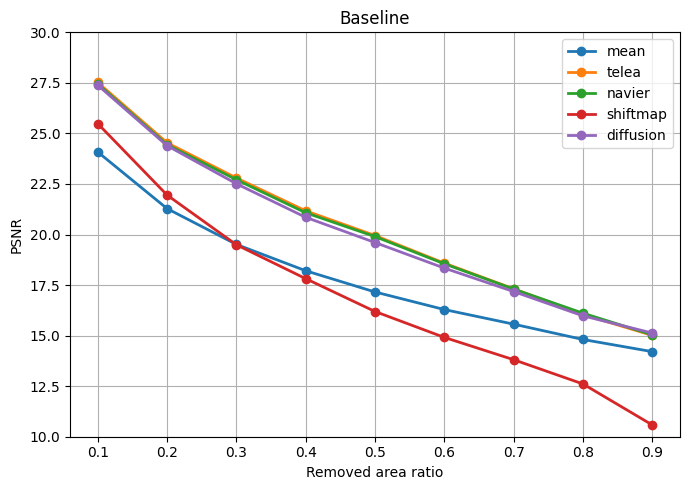

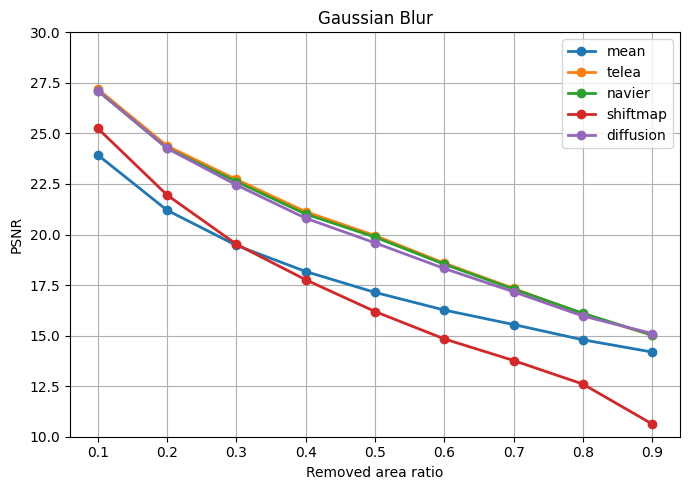

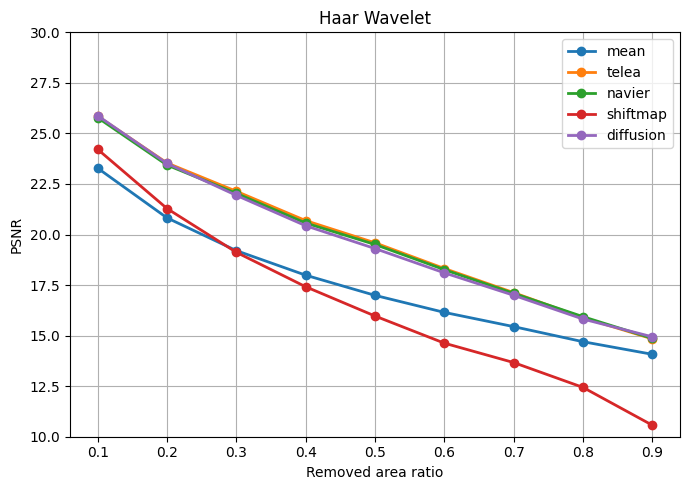

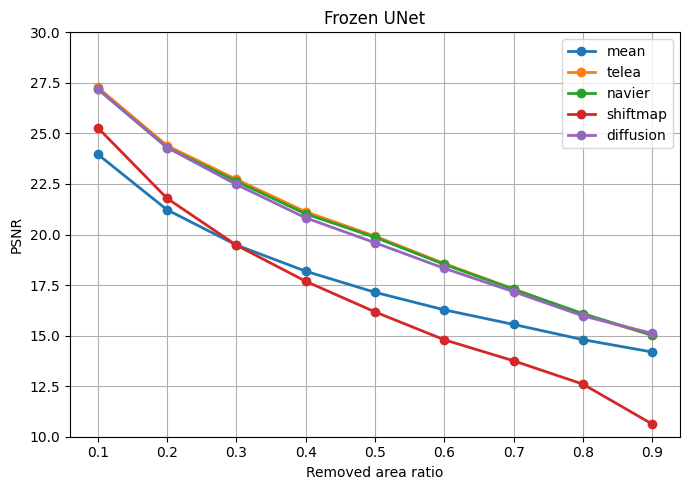

In [8]:
models = df["model"].unique()

fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(exist_ok=True)


for model in models:
    
    plt.figure(figsize=(7,5))
    
    model_df = df[df["model"] == model]
    
    for attack in model_df["attack"].unique():
        
        attack_df = (
            model_df[model_df["attack"] == attack]
            .sort_values("removal_ratio")
        )
        
        plt.plot(
            attack_df["removal_ratio"],
            attack_df["PSNR"],
            marker="o",
            linewidth=2,
            label=attack
        )
    
    plt.xlabel("Removed area ratio")
    plt.ylabel("PSNR")
    
    plt.title(
        f"{model}"
    )
    
    plt.ylim(10, 30)
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    
    filename = (
        model.lower()
        .replace(" ", "_")
        .replace("/", "_")
        + "_psnr_sweep.png"
    )
    
    plt.savefig(
        fig_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

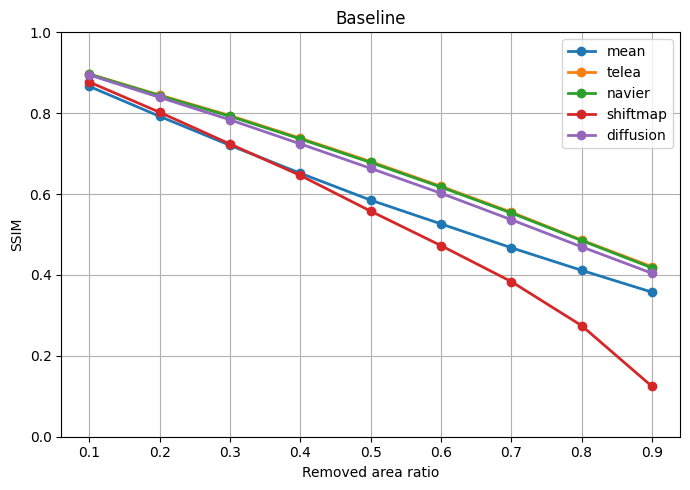

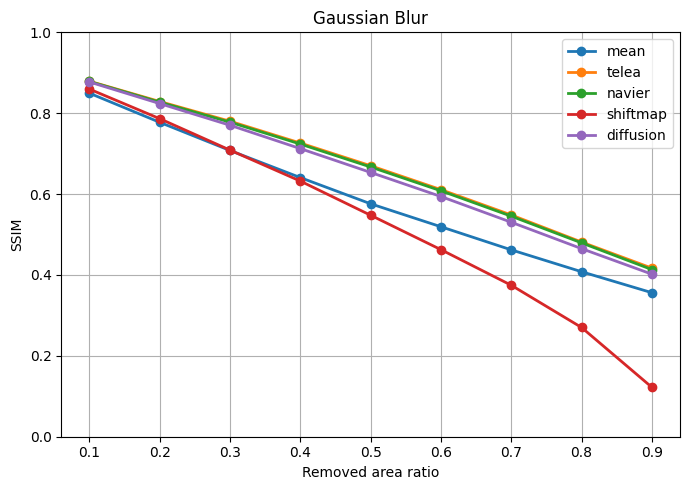

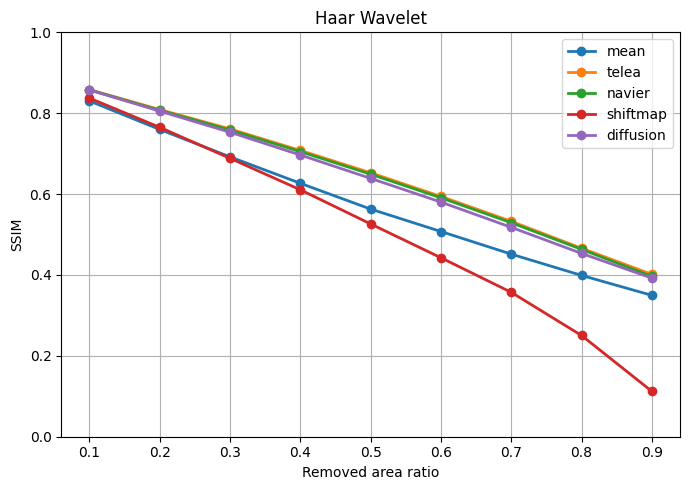

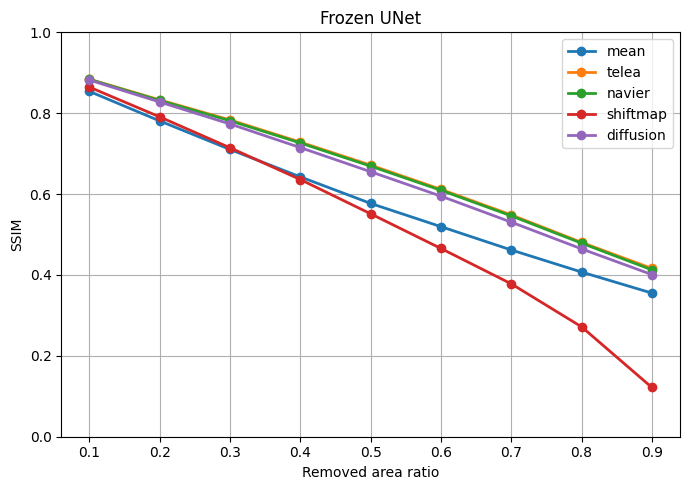

In [9]:
models = df["model"].unique()

fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(exist_ok=True)


for model in models:
    
    plt.figure(figsize=(7,5))
    
    model_df = df[df["model"] == model]
    
    for attack in model_df["attack"].unique():
        
        attack_df = (
            model_df[model_df["attack"] == attack]
            .sort_values("removal_ratio")
        )
        
        plt.plot(
            attack_df["removal_ratio"],
            attack_df["SSIM"],
            marker="o",
            linewidth=2,
            label=attack
        )
    
    plt.xlabel("Removed area ratio")
    plt.ylabel("SSIM")
    
    plt.title(
        f"{model}"
    )
    
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    
    filename = (
        model.lower()
        .replace(" ", "_")
        .replace("/", "_")
        + "_psnr_sweep.png"
    )
    
    plt.savefig(
        fig_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

In [10]:
# model info
val_df = pd.read_csv(
    "/home/keen/HiDDeN/output/csv/validation_results.csv"
)

val_df.head()

,model,PSNR,SSIM,BER
0,Baseline,34.2996,0.9436,0.027333
1,Gaussian Blur,33.0676,0.9212,0.076333
2,Haar Wavelet,29.7277,0.8960,0.089556
3,Frozen UNet,33.3698,0.9286,0.025333


In [11]:
#sparse mask
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# random sparse masks
random_mask_path_01 = Path("/home/keen/HiDDeN/sparse_random_masks_data/random_masks_den_0.1_seed_42/val_random_masks_density_100.npy")
random_mask_path_03 = Path("/home/keen/HiDDeN/sparse_random_masks_data/random_masks_den_0.3_seed_42/val_random_masks_density_300.npy")

# optimized sparse masks (final version used in thesis: PS + NLPE)
optimized_mask_path_01 = Path(
    "/home/keen/HiDDeN/opt_masks_data/opt_masks_diff_150_nlpe_100_den_0.1/val_ps_nlpe_masks_density_100.npy"
)

optimized_mask_path_03 = Path(
    "/home/keen/HiDDeN/opt_masks_data/opt_masks_diff_150_nlpe_100_den_0.3/val_ps_nlpe_masks_density_300.npy"
)

In [12]:
random_masks_01 = np.load(random_mask_path_01)
optimized_masks_01 = np.load(optimized_mask_path_01)

random_masks_03 = np.load(random_mask_path_03)
optimized_masks_03 = np.load(optimized_mask_path_03)

print("random 0.1:", random_masks_01.shape)
print("optimized 0.1:", optimized_masks_01.shape)
print("random 0.3:", random_masks_03.shape)
print("optimized 0.3:", optimized_masks_03.shape)

random 0.1: (300, 128, 128)
optimized 0.1: (300, 128, 128)
random 0.3: (300, 128, 128)
optimized 0.3: (300, 128, 128)


In [13]:
mean_random_01 = random_masks_01.mean(axis=0)
mean_optimized_01 = optimized_masks_01.mean(axis=0)

mean_random_03 = random_masks_03.mean(axis=0)
mean_optimized_03 = optimized_masks_03.mean(axis=0)

/tmp/ipykernel_3016/2043787363.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


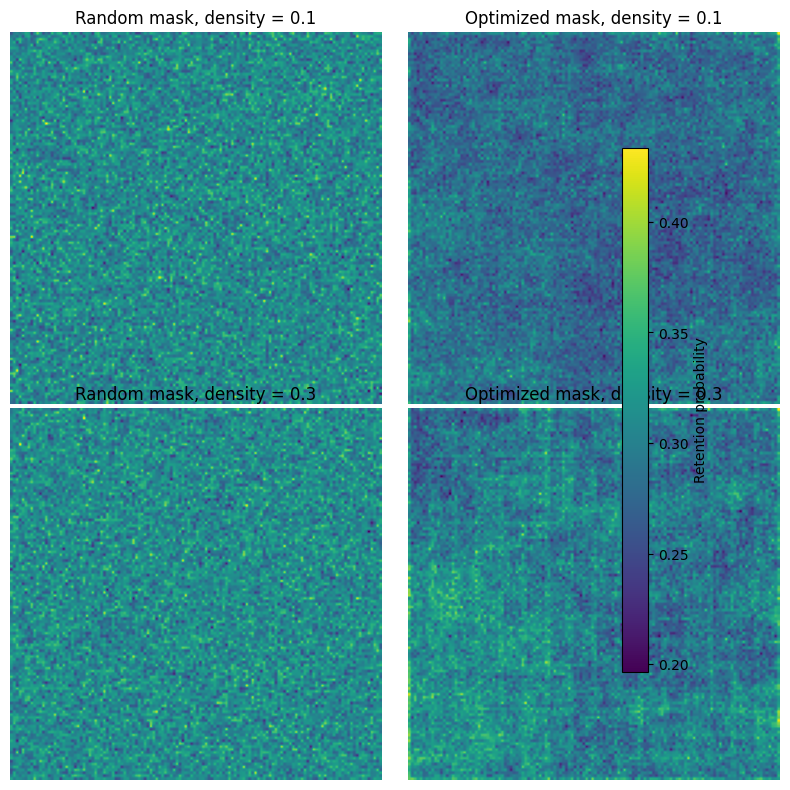

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

im1 = axes[0, 0].imshow(mean_random_01)
axes[0, 0].set_title("Random mask, density = 0.1")
axes[0, 0].axis("off")

im2 = axes[0, 1].imshow(mean_optimized_01)
axes[0, 1].set_title("Optimized mask, density = 0.1")
axes[0, 1].axis("off")

im3 = axes[1, 0].imshow(mean_random_03)
axes[1, 0].set_title("Random mask, density = 0.3")
axes[1, 0].axis("off")

im4 = axes[1, 1].imshow(mean_optimized_03)
axes[1, 1].set_title("Optimized mask, density = 0.3")
axes[1, 1].axis("off")

cbar = fig.colorbar(im4, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Retention probability")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3016/331939236.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


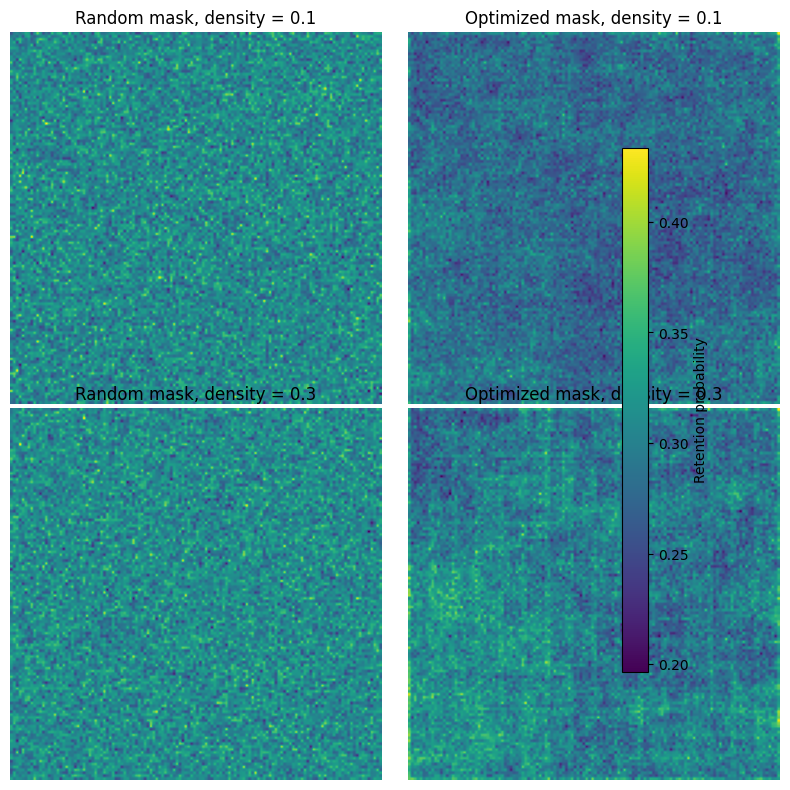

In [15]:
fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

im1 = axes[0, 0].imshow(mean_random_01)
axes[0, 0].set_title("Random mask, density = 0.1")
axes[0, 0].axis("off")

im2 = axes[0, 1].imshow(mean_optimized_01)
axes[0, 1].set_title("Optimized mask, density = 0.1")
axes[0, 1].axis("off")

im3 = axes[1, 0].imshow(mean_random_03)
axes[1, 0].set_title("Random mask, density = 0.3")
axes[1, 0].axis("off")

im4 = axes[1, 1].imshow(mean_optimized_03)
axes[1, 1].set_title("Optimized mask, density = 0.3")
axes[1, 1].axis("off")

cbar = fig.colorbar(im4, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Retention probability")

plt.tight_layout()
plt.savefig(fig_dir / "mean_mask_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# PSNR–BER trade-off scatter
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/home/keen/HiDDeN/output/csv/sparse_mask_results.csv")
sparse_df = pd.read_csv(csv_path)

sparse_df.head()

,model,mask_type,density,attack,PSNR,SSIM,BER,num_images
0,Frozen UNet,Optimized_d300_n200,0.3,navier,30.339326,0.873680,0.272889,300
1,Baseline,Optimized_d300_n200,0.1,telea,23.411635,0.682666,0.478222,300
2,Haar Wavelet,Optimized_d150_n100,0.1,mean,14.284555,0.437911,0.444667,300
3,Gaussian Blur,Optimized_d150_n100,0.3,mean,15.650209,0.478348,0.384667,300
4,Gaussian Blur,Optimized_d150_n100,0.1,mean,14.324939,0.435390,0.461889,300


In [17]:
print("Models:", sparse_df["model"].unique())
print("Mask types:", sparse_df["mask_type"].unique())
print("Attacks:", sparse_df["attack"].unique())
print("Densities:", sparse_df["density"].unique())

Models: ['Frozen UNet' 'Baseline' 'Haar Wavelet' 'Gaussian Blur']
Mask types: ['Optimized_d300_n200' 'Optimized_d150_n100' 'Random']
Attacks: ['navier' 'telea' 'mean' 'diffusion']
Densities: [0.3 0.1]


In [18]:
attacks_to_use = ["mean", "telea", "navier", "diffusion"]

plot_df = (
    sparse_df[
        (sparse_df["model"] == "Baseline") &
        (sparse_df["attack"].isin(attacks_to_use))
    ]
    .groupby(["mask_type", "density"])[["PSNR", "BER"]]
    .mean()
    .reset_index()
)

plot_df

,mask_type,density,PSNR,BER
0,Optimized_d150_n100,0.1,22.197247,0.484722
1,Optimized_d150_n100,0.3,26.819511,0.357861
2,Optimized_d300_n200,0.1,22.371062,0.483389
3,Optimized_d300_n200,0.3,26.827172,0.352861
4,Random,0.1,20.028371,0.486111
5,Random,0.3,22.349628,0.392028


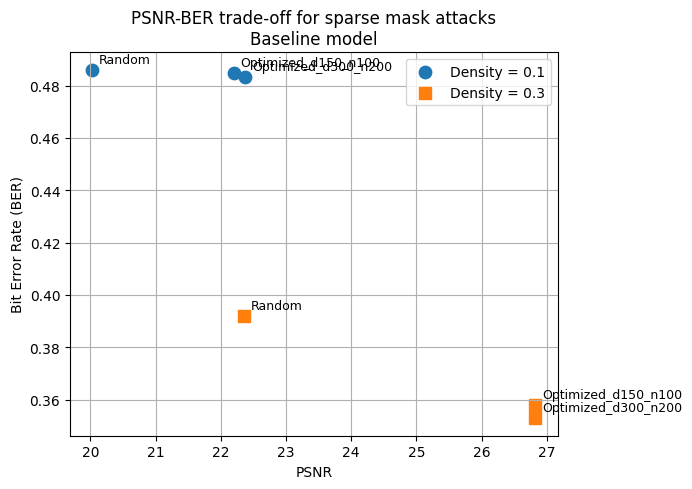

In [19]:
fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 5))

for density in sorted(plot_df["density"].unique()):
    density_df = plot_df[plot_df["density"] == density]
    
    plt.scatter(
        density_df["PSNR"],
        density_df["BER"],
        s=80,
        marker="o" if density == 0.1 else "s",
        label=f"Density = {density}"
    )
    
    for _, row in density_df.iterrows():
        plt.annotate(
            row["mask_type"],
            (row["PSNR"], row["BER"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

plt.xlabel("PSNR")
plt.ylabel("Bit Error Rate (BER)")
plt.title("PSNR-BER trade-off for sparse mask attacks\nBaseline model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "psnr_ber_tradeoff_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

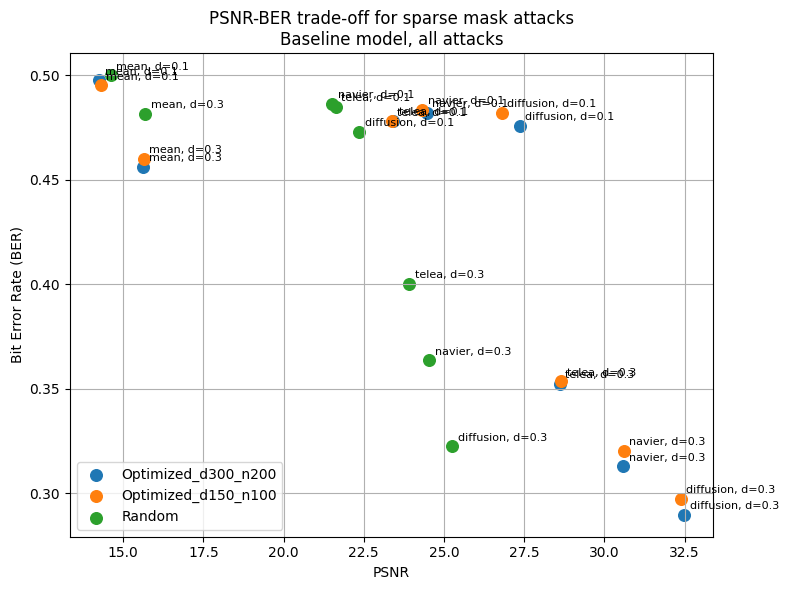

In [20]:
# all the different attacks
fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plot_df_full = sparse_df[
    (sparse_df["model"] == "Baseline") &
    (sparse_df["attack"].isin(attacks_to_use))
].copy()

plt.figure(figsize=(8, 6))

for mask_type in plot_df_full["mask_type"].unique():
    subset = plot_df_full[plot_df_full["mask_type"] == mask_type]
    plt.scatter(
        subset["PSNR"],
        subset["BER"],
        s=70,
        label=mask_type
    )
    
    for _, row in subset.iterrows():
        label = f'{row["attack"]}, d={row["density"]}'
        plt.annotate(
            label,
            (row["PSNR"], row["BER"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

plt.xlabel("PSNR")
plt.ylabel("Bit Error Rate (BER)")
plt.title("PSNR-BER trade-off for sparse mask attacks\nBaseline model, all attacks")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "psnr_ber_tradeoff_baseline_full_attacks.png", dpi=300, bbox_inches="tight")
plt.show()
   

In [21]:
# mask comparison
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

In [22]:
def load_rgb_image(path):
    img = Image.open(path).convert("RGB")
    arr = np.asarray(img).astype(np.float32) / 255.0
    return arr

def load_mask_from_npy(path, index):
    masks = np.load(path)
    mask = masks[index].astype(np.uint8)
    return mask

def show_panel(ax, img, title, panel_label, cmap=None, vmin=None, vmax=None):
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(
        0.02, 0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none")
    )

In [23]:
example_idx = 0
density = 0.3
attack_name = "diffusion"   # 改成你最终想展示的 attack

# cover image
cover_image_path = Path("/home/keen/HiDDeN/sparse_random_masks_data/random_masks_den_0.3_seed_42/visualizations/center_crops/0000_000000000139_crop.png")

# random mask
random_mask_path = Path("/home/keen/HiDDeN/sparse_random_masks_data/random_masks_den_0.3_seed_42/val_random_masks_density_300.npy")

# optimized mask (PS+NLPE)
optimized_mask_path = Path(
    "/home/keen/HiDDeN/opt_masks_data/opt_masks_diff_150_nlpe_100_den_0.3/val_ps_nlpe_masks_density_300.npy"
)

# attacked images
random_attacked_image_path = Path("/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.3_seed_42__val_random_masks_density_300__seed_42/images/attacked/0000_attacked.png")
optimized_attacked_image_path = Path("/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.3__val_ps_nlpe_masks_density_300__seed_42/images/attacked/0000_attacked.png")

In [24]:
cover_img = load_rgb_image(cover_image_path)

random_mask = load_mask_from_npy(random_mask_path, example_idx)
optimized_mask = load_mask_from_npy(optimized_mask_path, example_idx)

random_attacked_img = load_rgb_image(random_attacked_image_path)
optimized_attacked_img = load_rgb_image(optimized_attacked_image_path)

print("cover:", cover_img.shape)
print("random mask:", random_mask.shape)
print("optimized mask:", optimized_mask.shape)
print("random attacked:", random_attacked_img.shape)
print("optimized attacked:", optimized_attacked_img.shape)

cover: (128, 128, 3)
random mask: (128, 128)
optimized mask: (128, 128)
random attacked: (128, 128, 3)
optimized attacked: (128, 128, 3)


In [25]:
# 4-category map
# 0: neither retained
# 1: retained only in random mask
# 2: retained only in optimized mask
# 3: retained in both

overlap_map = np.zeros_like(random_mask, dtype=np.uint8)
overlap_map[(random_mask == 1) & (optimized_mask == 0)] = 1
overlap_map[(random_mask == 0) & (optimized_mask == 1)] = 2
overlap_map[(random_mask == 1) & (optimized_mask == 1)] = 3

# discrete colormap
cmap = ListedColormap([
    "black",        # 0: neither retained
    "orange",       # 1: random only
    "deepskyblue",  # 2: optimized only
    "white"         # 3: both retained
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

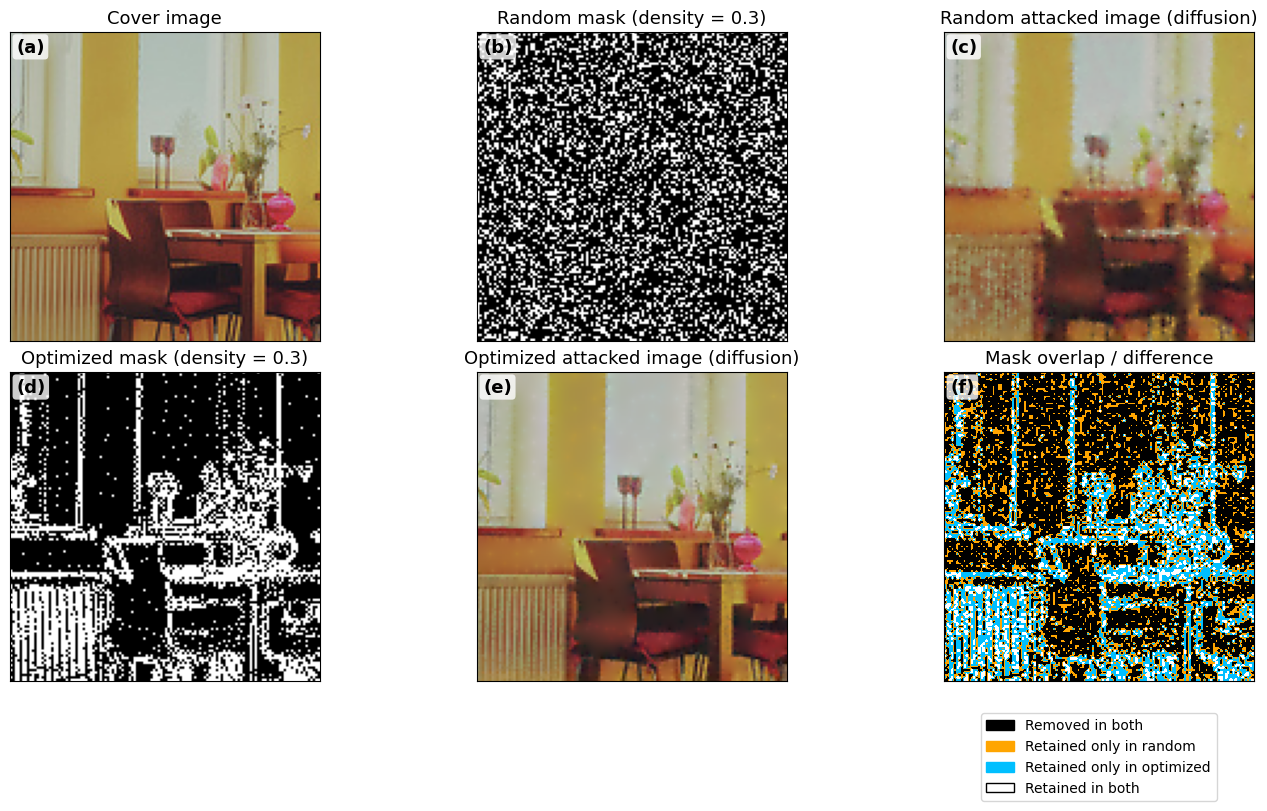

Saved to: /home/keen/HiDDeN/output/figures/qualitative_random_vs_optimized_d0.3_diffusion.png


In [26]:
fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

show_panel(axes[0, 0], cover_img, "Cover image", "(a)")
show_panel(axes[0, 1], random_mask, f"Random mask (density = {density})", "(b)", cmap="gray", vmin=0, vmax=1)
show_panel(axes[0, 2], random_attacked_img, f"Random attacked image ({attack_name})", "(c)")

show_panel(axes[1, 0], optimized_mask, f"Optimized mask (density = {density})", "(d)", cmap="gray", vmin=0, vmax=1)
show_panel(axes[1, 1], optimized_attacked_img, f"Optimized attacked image ({attack_name})", "(e)")
show_panel(axes[1, 2], overlap_map, "Mask overlap / difference", "(f)", cmap=cmap, vmin=0, vmax=3)

legend_patches = [
    mpatches.Patch(color="black", label="Removed in both"),
    mpatches.Patch(color="orange", label="Retained only in random"),
    mpatches.Patch(color="deepskyblue", label="Retained only in optimized"),
    mpatches.Patch(color="white", ec="black", label="Retained in both"),
]

axes[1, 2].legend(
    handles=legend_patches,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,
    fontsize=10,
    ncol=1
)

save_path = fig_dir / f"qualitative_random_vs_optimized_d{density}_{attack_name}.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", save_path)

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


csv_path = "output/csv/sparse_mask_results.csv"

sparse_df = pd.read_csv(csv_path)


# only final optimized mask
selected_masks = [
    "Random",
    "Optimized_d300_n200"
]


trade_df = (
    sparse_df[
        sparse_df["mask_type"].isin(selected_masks)
    ]
    .groupby(
        ["model", "mask_type", "density","attack"]
    )[["PSNR", "BER"]]
    .mean()
    .reset_index()
)


trade_df

,model,mask_type,density,attack,PSNR,BER
0,Baseline,Optimized_d300_n200,0.1,diffusion,27.363144,0.475778
1,Baseline,Optimized_d300_n200,0.1,mean,14.252025,0.497556
2,Baseline,Optimized_d300_n200,0.1,navier,24.457443,0.482000
3,Baseline,Optimized_d300_n200,0.1,telea,23.411635,0.478222
4,Baseline,Optimized_d300_n200,0.3,diffusion,32.485482,0.289778
...,...,...,...,...,...,...
59,Haar Wavelet,Random,0.1,telea,21.362344,0.428444
60,Haar Wavelet,Random,0.3,diffusion,24.482131,0.237556
61,Haar Wavelet,Random,0.3,mean,15.625080,0.372889
62,Haar Wavelet,Random,0.3,navier,23.800208,0.241111


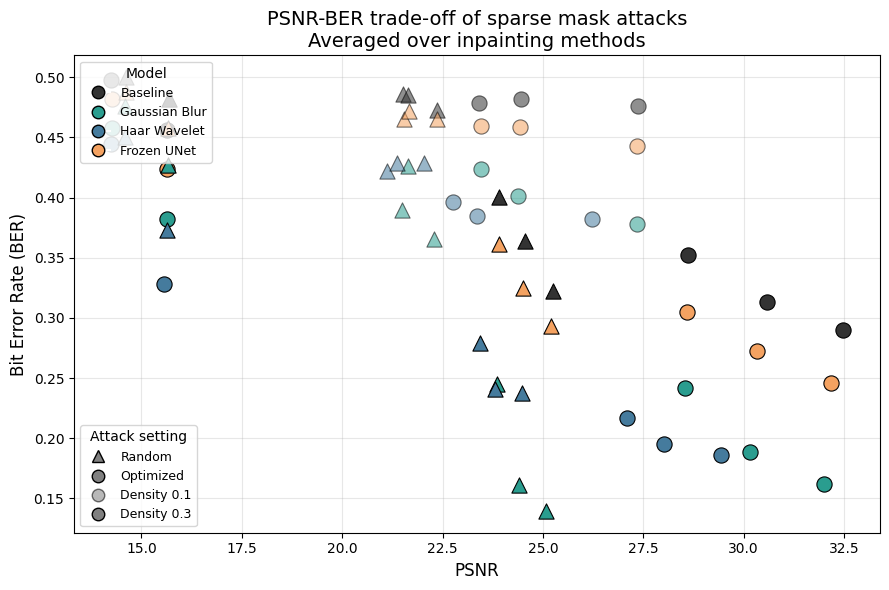

In [28]:
model_colors = {
    "Baseline": "#333333",
    "Gaussian Blur": "#2a9d8f",
    "Haar Wavelet": "#457b9d",
    "Frozen UNet": "#f4a261",
}


density_alpha = {
    0.1: 0.55,
    0.3: 1.0
}


plt.figure(figsize=(9, 6))


for _, row in trade_df.iterrows():

    model = row["model"]
    mask = row["mask_type"]
    density = row["density"]

    marker = "^" if mask == "Random" else "o"

    plt.scatter(
        row["PSNR"],
        row["BER"],
        marker=marker,
        s=120,
        color=model_colors[model],
        alpha=density_alpha[density],
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )


# legends
model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=name,
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=9
    )
    for name, color in model_colors.items()
]


mask_handles = [
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="Random",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=9
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Optimized",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=9
    )
]


density_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Density 0.1",
        markerfacecolor="gray",
        alpha=0.55,
        markeredgecolor="black",
        markersize=9
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Density 0.3",
        markerfacecolor="gray",
        alpha=1.0,
        markeredgecolor="black",
        markersize=9
    )
]


legend1 = plt.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
    fontsize=9
)

plt.gca().add_artist(legend1)


plt.legend(
    handles=mask_handles+density_handles,
    title="Attack setting",
    loc="lower left",
    fontsize=9
)


plt.xlabel("PSNR", fontsize=12)
plt.ylabel("Bit Error Rate (BER)", fontsize=12)

plt.title(
    "PSNR-BER trade-off of sparse mask attacks\n"
    "Averaged over inpainting methods",
    fontsize=14
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

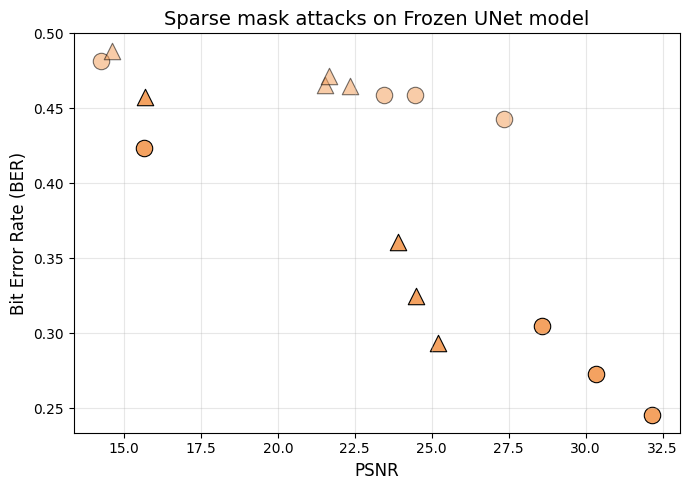

In [29]:
unet_df = trade_df[
    trade_df["model"] == "Frozen UNet"
]


plt.figure(figsize=(7,5))


for _, row in unet_df.iterrows():

    marker = "^" if row["mask_type"] == "Random" else "o"

    plt.scatter(
        row["PSNR"],
        row["BER"],
        marker=marker,
        s=140,
        color="#f4a261",
        alpha=density_alpha[row["density"]],
        edgecolor="black",
        linewidth=0.8
    )


plt.xlabel("PSNR", fontsize=12)
plt.ylabel("Bit Error Rate (BER)", fontsize=12)

plt.title(
    "Sparse mask attacks on Frozen UNet model",
    fontsize=14
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

check individual attack?

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("output/csv/sparse_mask_results.csv")
sparse_df = pd.read_csv(csv_path)

sparse_df.head()

,model,mask_type,density,attack,PSNR,SSIM,BER,num_images
0,Frozen UNet,Optimized_d300_n200,0.3,navier,30.339326,0.873680,0.272889,300
1,Baseline,Optimized_d300_n200,0.1,telea,23.411635,0.682666,0.478222,300
2,Haar Wavelet,Optimized_d150_n100,0.1,mean,14.284555,0.437911,0.444667,300
3,Gaussian Blur,Optimized_d150_n100,0.3,mean,15.650209,0.478348,0.384667,300
4,Gaussian Blur,Optimized_d150_n100,0.1,mean,14.324939,0.435390,0.461889,300


In [31]:
print("Models:", sparse_df["model"].unique())
print("Mask types:", sparse_df["mask_type"].unique())
print("Densities:", sorted(sparse_df["density"].unique()))
print("Attacks:", sparse_df["attack"].unique())

Models: ['Frozen UNet' 'Baseline' 'Haar Wavelet' 'Gaussian Blur']
Mask types: ['Optimized_d300_n200' 'Optimized_d150_n100' 'Random']
Densities: [0.1, 0.3]
Attacks: ['navier' 'telea' 'mean' 'diffusion']


In [32]:
summary_table = (
    sparse_df
    .groupby(["model", "mask_type", "density"])[["PSNR", "SSIM", "BER"]]
    .mean()
    .round(4)
    .reset_index()
)

summary_table

,model,mask_type,density,PSNR,SSIM,BER
0,Baseline,Optimized_d150_n100,0.1,22.1972,0.6450,0.4847
1,Baseline,Optimized_d150_n100,0.3,26.8195,0.7834,0.3579
2,Baseline,Optimized_d300_n200,0.1,22.3711,0.6501,0.4834
3,Baseline,Optimized_d300_n200,0.3,26.8272,0.7850,0.3529
4,Baseline,Random,0.1,20.0284,0.5244,0.4861
5,Baseline,Random,0.3,22.3496,0.6464,0.3920
6,Frozen UNet,Optimized_d150_n100,0.1,22.2037,0.6426,0.4624
7,Frozen UNet,Optimized_d150_n100,0.3,26.6703,0.7780,0.3126
8,Frozen UNet,Optimized_d300_n200,0.1,22.3781,0.6479,0.4607
9,Frozen UNet,Optimized_d300_n200,0.3,26.6827,0.7798,0.3118


In [33]:
summary_table_sorted = summary_table.sort_values(
    by=["model", "density", "BER"],
    ascending=[True, True, False]
)

summary_table_sorted

,model,mask_type,density,PSNR,SSIM,BER
4,Baseline,Random,0.1,20.0284,0.5244,0.4861
0,Baseline,Optimized_d150_n100,0.1,22.1972,0.6450,0.4847
2,Baseline,Optimized_d300_n200,0.1,22.3711,0.6501,0.4834
5,Baseline,Random,0.3,22.3496,0.6464,0.3920
1,Baseline,Optimized_d150_n100,0.3,26.8195,0.7834,0.3579
3,Baseline,Optimized_d300_n200,0.3,26.8272,0.7850,0.3529
10,Frozen UNet,Random,0.1,20.0405,0.5225,0.4726
6,Frozen UNet,Optimized_d150_n100,0.1,22.2037,0.6426,0.4624
8,Frozen UNet,Optimized_d300_n200,0.1,22.3781,0.6479,0.4607
11,Frozen UNet,Random,0.3,22.3222,0.6407,0.3591


In [34]:
short_mask = {
    "Random": "R",
    "Optimized_d150_n100": "O150",
    "Optimized_d300_n200": "O300",
}

plot_df = sparse_df.copy()
plot_df["series"] = plot_df.apply(
    lambda row: f'{short_mask[row["mask_type"]]}-d{row["density"]}',
    axis=1
)

plot_df.head()

,model,mask_type,density,attack,PSNR,SSIM,BER,num_images,series
0,Frozen UNet,Optimized_d300_n200,0.3,navier,30.339326,0.873680,0.272889,300,O300-d0.3
1,Baseline,Optimized_d300_n200,0.1,telea,23.411635,0.682666,0.478222,300,O300-d0.1
2,Haar Wavelet,Optimized_d150_n100,0.1,mean,14.284555,0.437911,0.444667,300,O150-d0.1
3,Gaussian Blur,Optimized_d150_n100,0.3,mean,15.650209,0.478348,0.384667,300,O150-d0.3
4,Gaussian Blur,Optimized_d150_n100,0.1,mean,14.324939,0.435390,0.461889,300,O150-d0.1


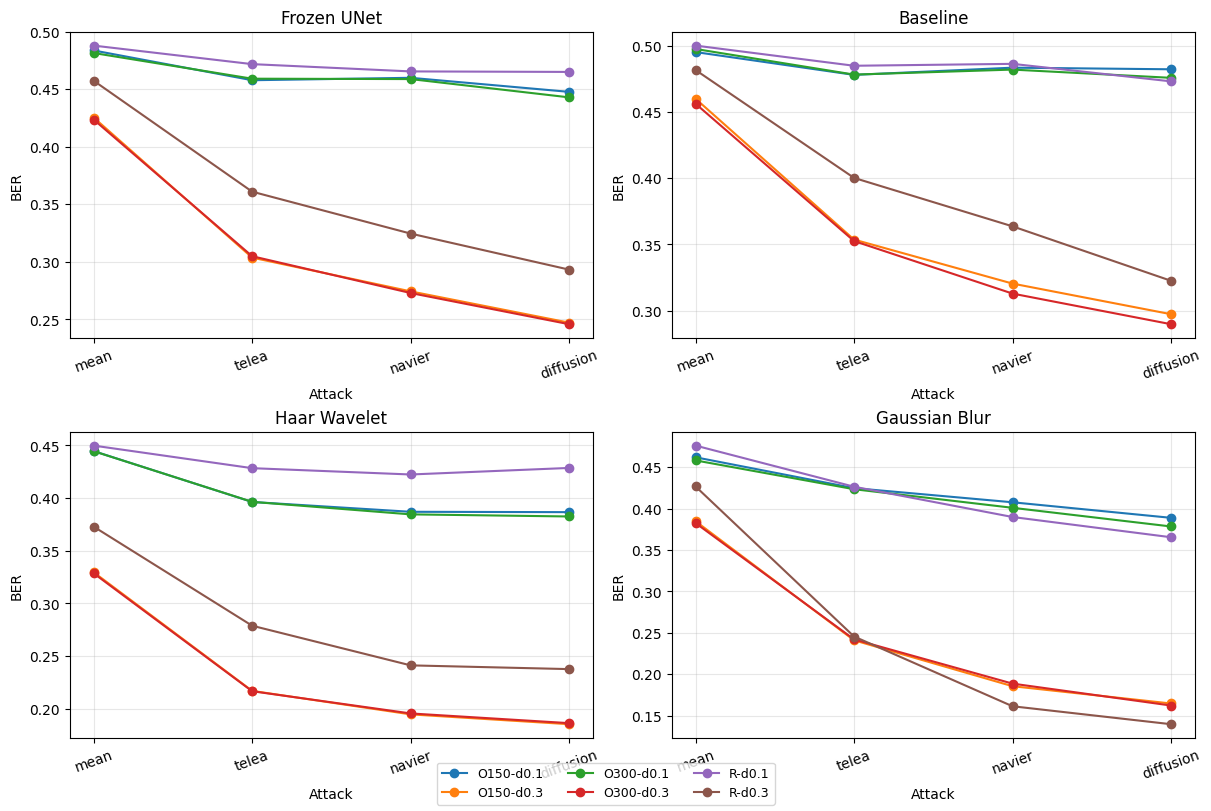

In [35]:
models = list(plot_df["model"].unique())
attacks = ["mean", "telea", "navier", "diffusion"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for ax, model in zip(axes, models):
    model_df = plot_df[plot_df["model"] == model]

    for series in sorted(model_df["series"].unique()):
        sub = model_df[model_df["series"] == series].copy()
        sub["attack"] = pd.Categorical(sub["attack"], categories=attacks, ordered=True)
        sub = sub.sort_values("attack")

        ax.plot(
            sub["attack"],
            sub["BER"],
            marker="o",
            linewidth=1.5,
            label=series
        )

    ax.set_title(model, fontsize=12)
    ax.set_xlabel("Attack", fontsize=10)
    ax.set_ylabel("BER", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelrotation=20)

# 统一图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9)

plt.show()

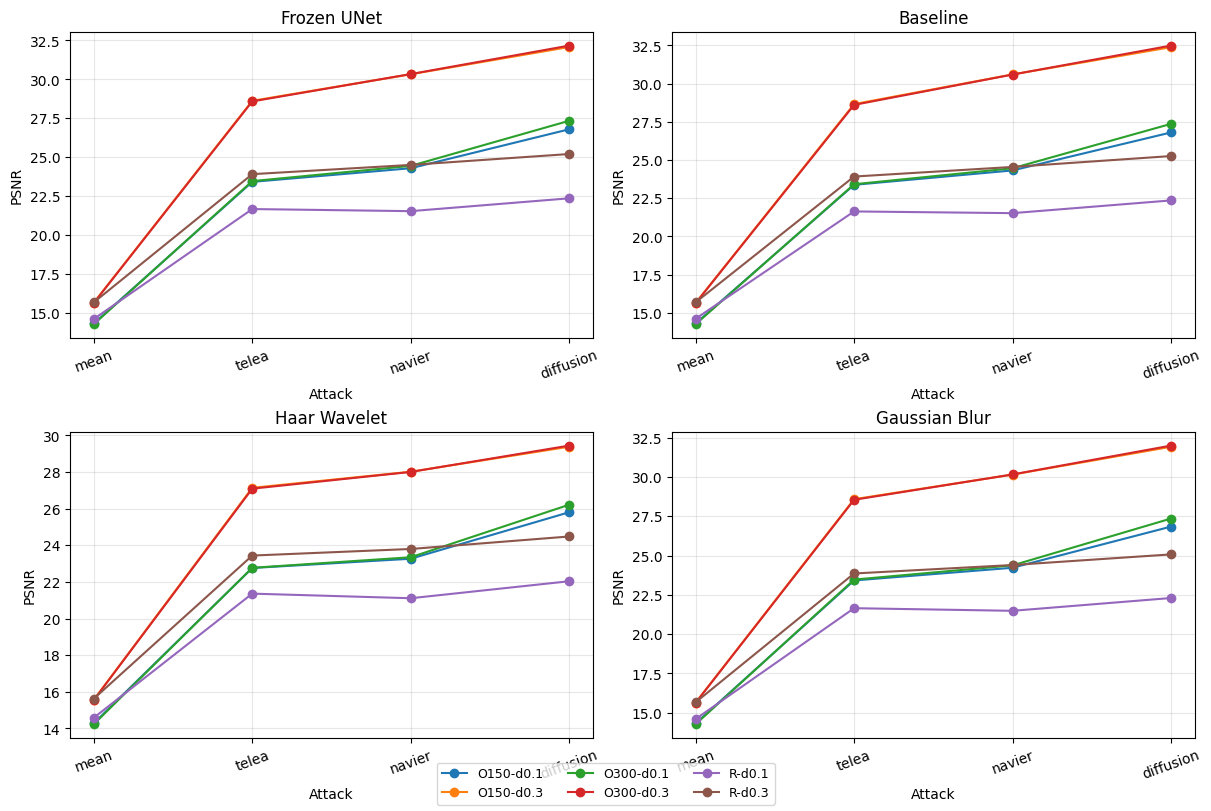

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for ax, model in zip(axes, models):
    model_df = plot_df[plot_df["model"] == model]

    for series in sorted(model_df["series"].unique()):
        sub = model_df[model_df["series"] == series].copy()
        sub["attack"] = pd.Categorical(sub["attack"], categories=attacks, ordered=True)
        sub = sub.sort_values("attack")

        ax.plot(
            sub["attack"],
            sub["PSNR"],
            marker="o",
            linewidth=1.5,
            label=series
        )

    ax.set_title(model, fontsize=12)
    ax.set_xlabel("Attack", fontsize=10)
    ax.set_ylabel("PSNR", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelrotation=20)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9)

plt.show()

Columns:
['model', 'mask_type', 'density', 'attack', 'PSNR', 'SSIM', 'BER', 'num_images']

Models:
['Frozen UNet' 'Baseline' 'Haar Wavelet' 'Gaussian Blur']

Attacks:
['navier' 'telea' 'mean' 'diffusion']


,attack,density,mask_label,PSNR,BER
0,diffusion,0.1,R,22.262316,0.433056
1,diffusion,0.1,O150,26.560194,0.426361
2,diffusion,0.1,O300,27.068011,0.419917
3,diffusion,0.3,R,25.003939,0.248222
4,diffusion,0.3,O150,31.440389,0.223556
5,diffusion,0.3,O300,31.523290,0.220972
6,mean,0.1,R,14.600301,0.478500
7,mean,0.1,O150,14.306625,0.471389
8,mean,0.1,O300,14.257681,0.470444
9,mean,0.3,R,15.662472,0.434667


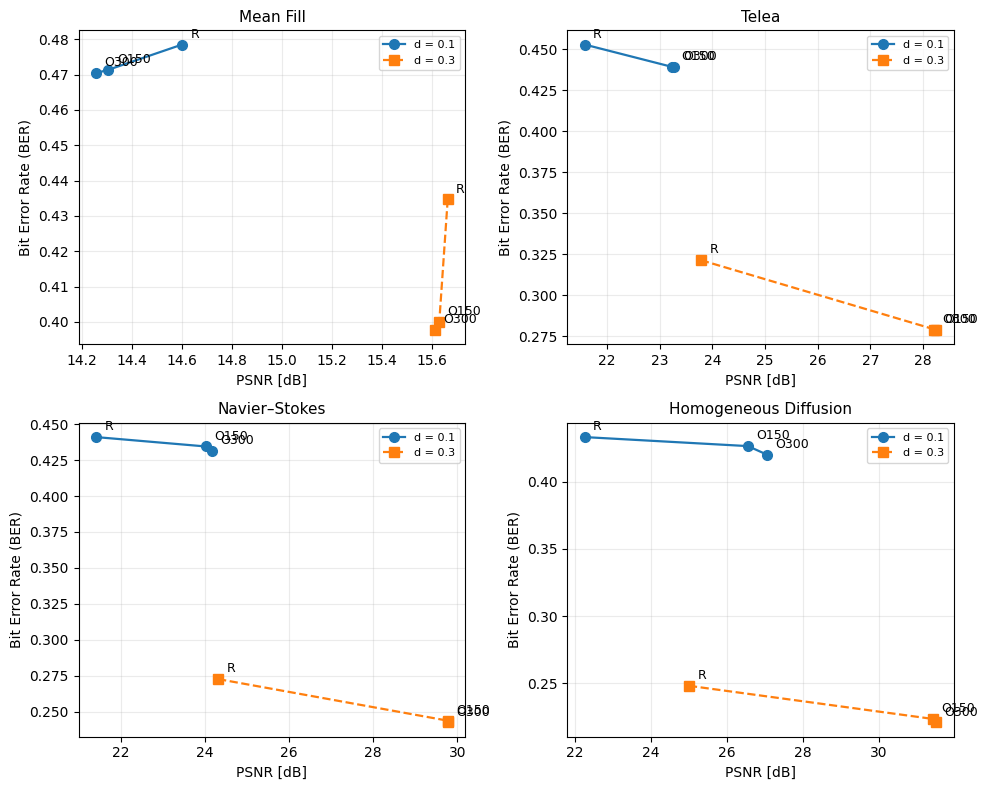

In [37]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Load CSV
# ============================================================

csv_path = Path("/home/keen/HiDDeN/output/csv/sparse_mask_results.csv")

df = pd.read_csv(csv_path)

print("Columns:")
print(df.columns.tolist())

print("\nModels:")
print(df["model"].unique())

print("\nAttacks:")
print(df["attack"].unique())


# ============================================================
# 2. Rename mask configurations
# ============================================================

mask_name_map = {
    "Random": "R",
    "Optimized_d150_n100": "O150",
    "Optimized_d300_n200": "O300",
}

df["mask_label"] = df["mask_type"].map(mask_name_map)

mask_order = ["R", "O150", "O300"]

df["mask_label"] = pd.Categorical(
    df["mask_label"],
    categories=mask_order,
    ordered=True,
)


# ============================================================
# 3. Average over the four trained watermarking models
#
# Keep:
#   attack
#   density
#   mask configuration
#
# Average:
#   model dimension
# ============================================================

summary = (
    df
    .groupby(
        ["attack", "density", "mask_label"],
        observed=True,
        as_index=False,
    )[["PSNR", "BER"]]
    .mean()
)

summary = summary.sort_values(
    ["attack", "density", "mask_label"]
)

display(summary)


# ============================================================
# 4. Operator names / plotting order
# ============================================================

attack_order = [
    "mean",
    "telea",
    "navier",
    "diffusion",
]

attack_titles = {
    "mean": "Mean Fill",
    "telea": "Telea",
    "navier": "Navier–Stokes",
    "diffusion": "Homogeneous Diffusion",
}

density_order = [0.1, 0.3]

density_styles = {
    0.1: {
        "marker": "o",
        "linestyle": "-",
    },
    0.3: {
        "marker": "s",
        "linestyle": "--",
    },
}


# ============================================================
# 5. Plot
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
)

axes = axes.flatten()


for ax, attack in zip(axes, attack_order):

    attack_data = summary[
        summary["attack"] == attack
    ]

    for density in density_order:

        current = (
            attack_data[
                attack_data["density"] == density
            ]
            .sort_values("mask_label")
        )

        style = density_styles[density]

        # ----------------------------------------------------
        # Plot trajectory:
        #
        # R -> O150 -> O300
        # ----------------------------------------------------

        ax.plot(
            current["PSNR"],
            current["BER"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=1.6,
            markersize=7,
            label=f"d = {density}",
        )

        # ----------------------------------------------------
        # Point labels
        # ----------------------------------------------------

        for _, row in current.iterrows():

            ax.annotate(
                row["mask_label"],
                xy=(
                    row["PSNR"],
                    row["BER"],
                ),
                xytext=(6, 5),
                textcoords="offset points",
                fontsize=9,
            )

    # --------------------------------------------------------
    # Panel formatting
    # --------------------------------------------------------

    ax.set_title(
        attack_titles[attack],
        fontsize=11,
    )

    ax.set_xlabel(
        "PSNR [dB]",
        fontsize=10,
    )

    ax.set_ylabel(
        "Bit Error Rate (BER)",
        fontsize=10,
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.legend(
        fontsize=8,
        loc="best",
    )


# ============================================================
# 6. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 7. Save
# ============================================================

plt.savefig(
    "sparse_tradeoff_by_operator.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    "sparse_tradeoff_by_operator.pdf",
    bbox_inches="tight",
)

plt.show()

['model', 'mask_type', 'density', 'attack', 'PSNR', 'SSIM', 'BER', 'num_images']
['Frozen UNet' 'Baseline' 'Haar Wavelet' 'Gaussian Blur']
['navier' 'telea' 'mean' 'diffusion']
['Optimized_d300_n200' 'Optimized_d150_n100' 'Random']


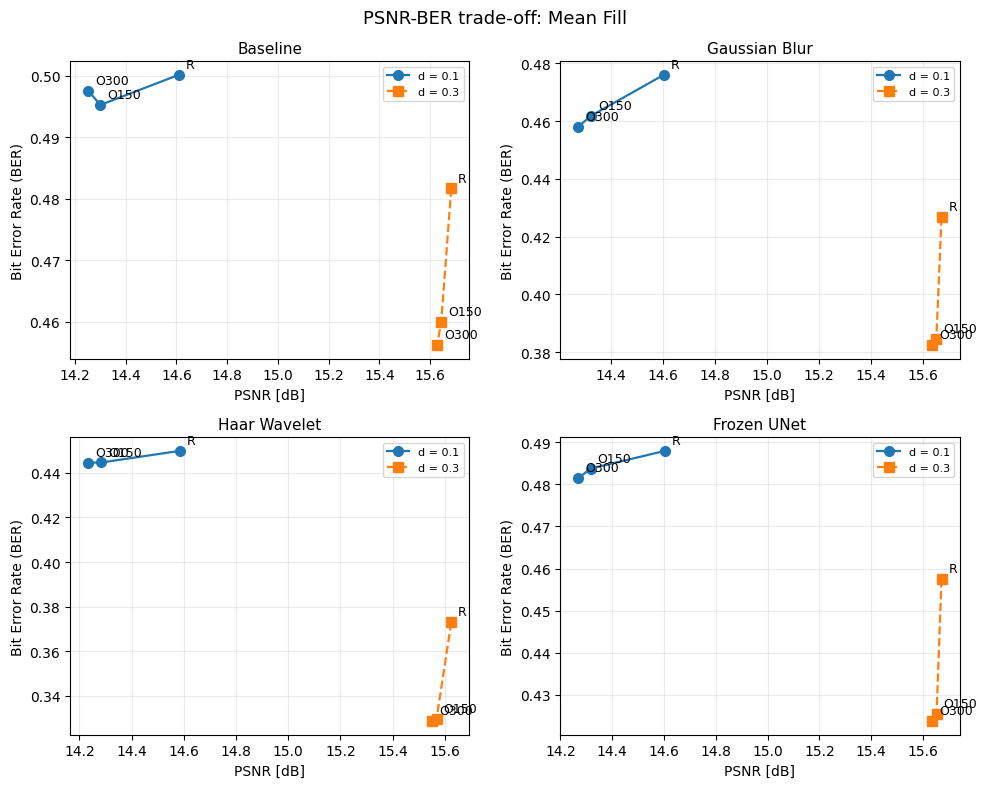

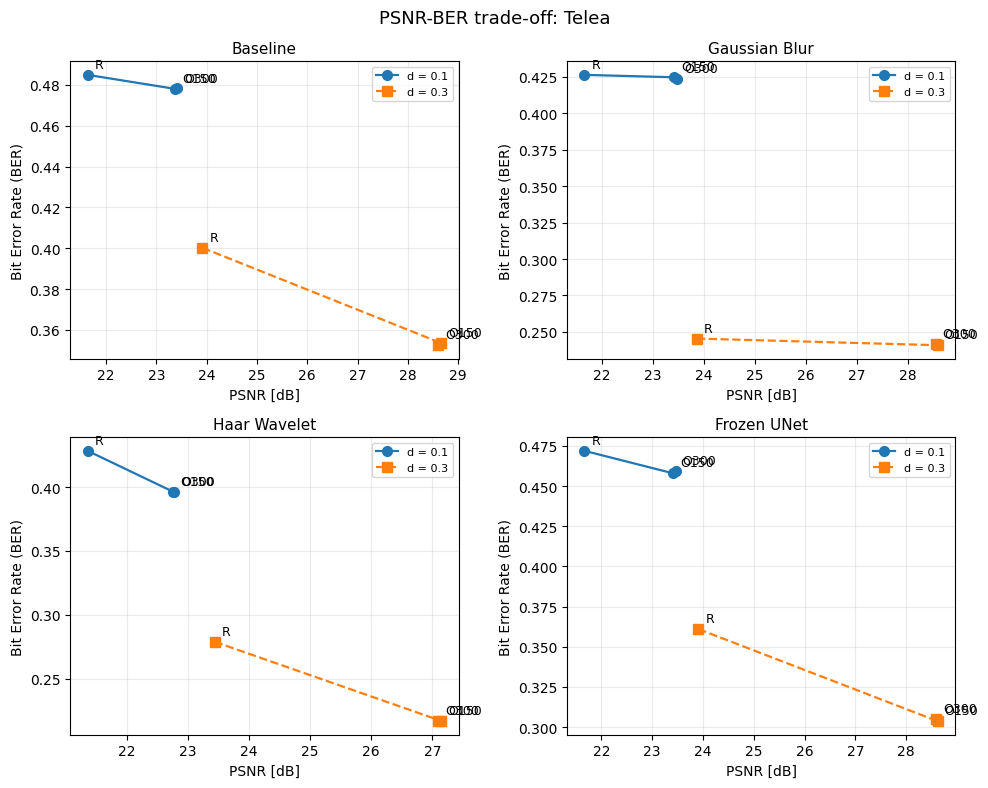

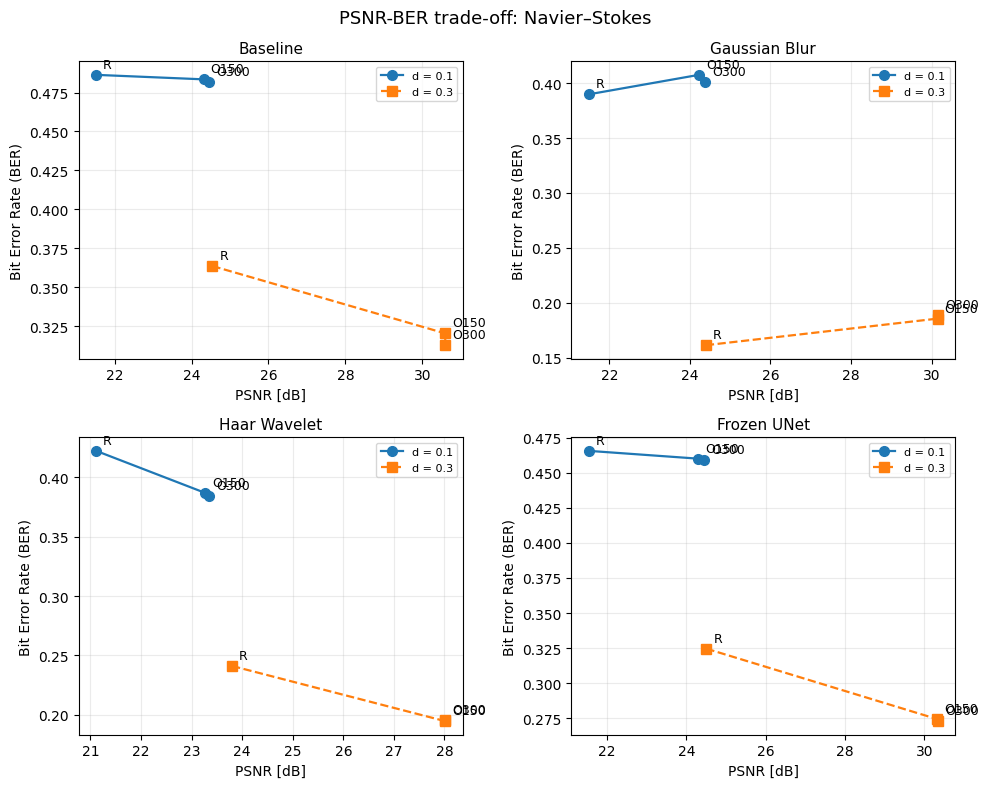

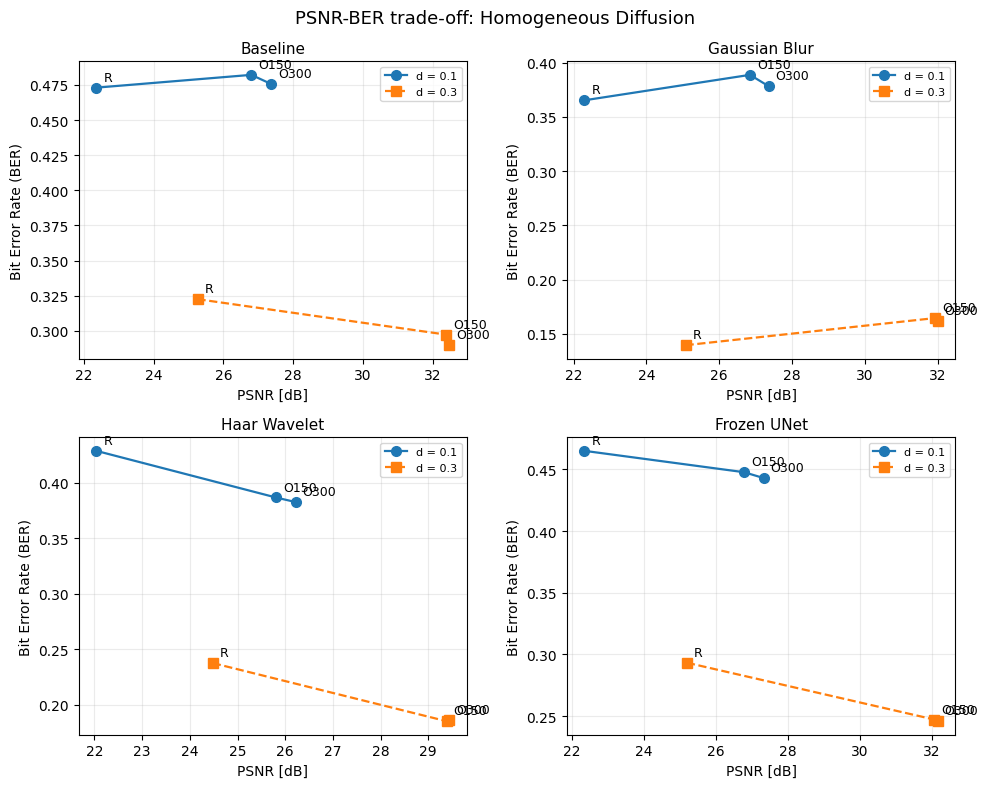

In [38]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Load data
# ============================================================

csv_path = Path("/home/keen/HiDDeN/output/csv/sparse_mask_results.csv")

df = pd.read_csv(csv_path)

print(df.columns.tolist())
print(df["model"].unique())
print(df["attack"].unique())
print(df["mask_type"].unique())


# ============================================================
# 2. Rename mask configurations
# ============================================================

mask_name_map = {
    "Random": "R",
    "Optimized_d150_n100": "O150",
    "Optimized_d300_n200": "O300",
}

df["mask_label"] = df["mask_type"].map(mask_name_map)

mask_order = ["R", "O150", "O300"]

df["mask_label"] = pd.Categorical(
    df["mask_label"],
    categories=mask_order,
    ordered=True,
)


# ============================================================
# 3. Plotting order
# ============================================================

model_order = [
    "Baseline",
    "Gaussian Blur",
    "Haar Wavelet",
    "Frozen UNet",
]

attack_order = [
    "mean",
    "telea",
    "navier",
    "diffusion",
]

attack_titles = {
    "mean": "Mean Fill",
    "telea": "Telea",
    "navier": "Navier–Stokes",
    "diffusion": "Homogeneous Diffusion",
}

density_order = [0.1, 0.3]

density_styles = {
    0.1: {
        "marker": "o",
        "linestyle": "-",
    },
    0.3: {
        "marker": "s",
        "linestyle": "--",
    },
}


# ============================================================
# 4. One figure per inpainting operator
#
# Each figure:
#
#   Baseline       Gaussian Blur
#   Haar Wavelet   Frozen U-Net
#
# No averaging over models.
# ============================================================

for attack in attack_order:

    attack_df = df[
        df["attack"] == attack
    ].copy()

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10, 8),
    )

    axes = axes.flatten()

    for ax, model in zip(axes, model_order):

        model_df = attack_df[
            attack_df["model"] == model
        ]

        for density in density_order:

            current = (
                model_df[
                    model_df["density"] == density
                ]
                .sort_values("mask_label")
            )

            style = density_styles[density]

            ax.plot(
                current["PSNR"],
                current["BER"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=1.6,
                markersize=7,
                label=f"d = {density}",
            )

            # Labels: R, O150, O300
            for _, row in current.iterrows():

                ax.annotate(
                    row["mask_label"],
                    (
                        row["PSNR"],
                        row["BER"],
                    ),
                    xytext=(5, 5),
                    textcoords="offset points",
                    fontsize=9,
                )

        ax.set_title(
            model,
            fontsize=11,
        )

        ax.set_xlabel(
            "PSNR [dB]"
        )

        ax.set_ylabel(
            "Bit Error Rate (BER)"
        )

        ax.grid(
            True,
            alpha=0.25,
        )

        ax.legend(
            fontsize=8,
        )

    fig.suptitle(
        f"PSNR-BER trade-off: {attack_titles[attack]}",
        fontsize=13,
    )

    plt.tight_layout()

    output_name = (
        f"sparse_tradeoff_{attack}.png"
    )

    plt.savefig(
        output_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

['model', 'mask_type', 'density', 'attack', 'PSNR', 'SSIM', 'BER', 'num_images']
['Frozen UNet' 'Baseline' 'Haar Wavelet' 'Gaussian Blur']
['navier' 'telea' 'mean' 'diffusion']
['Optimized_d300_n200' 'Optimized_d150_n100' 'Random']


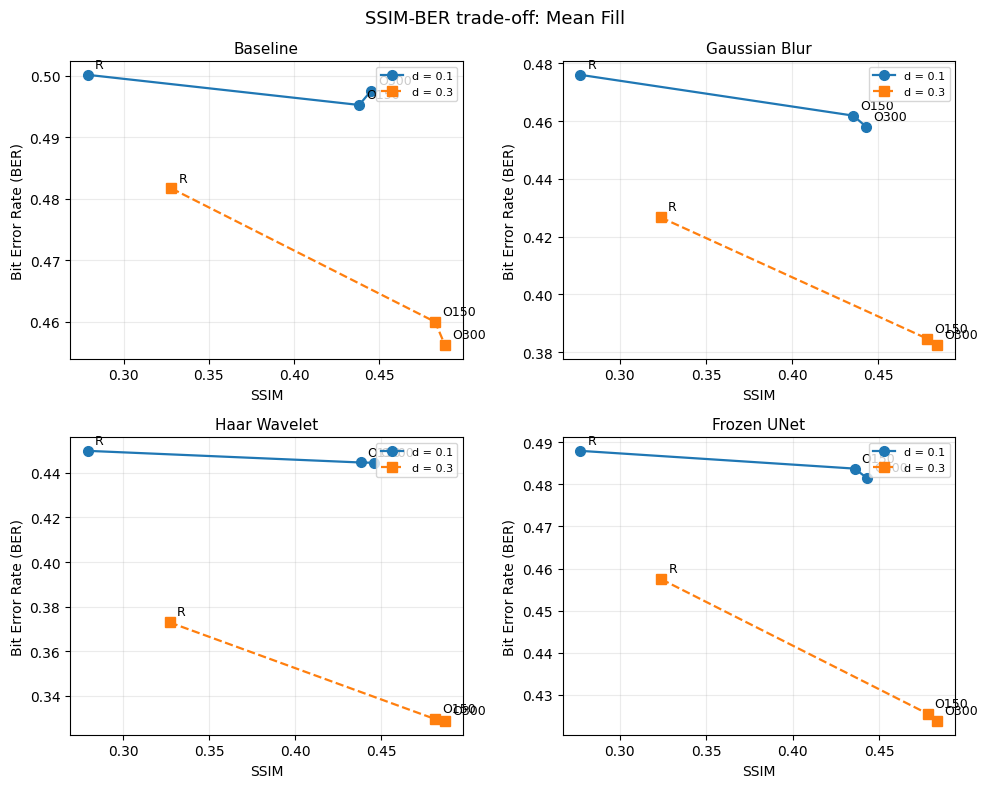

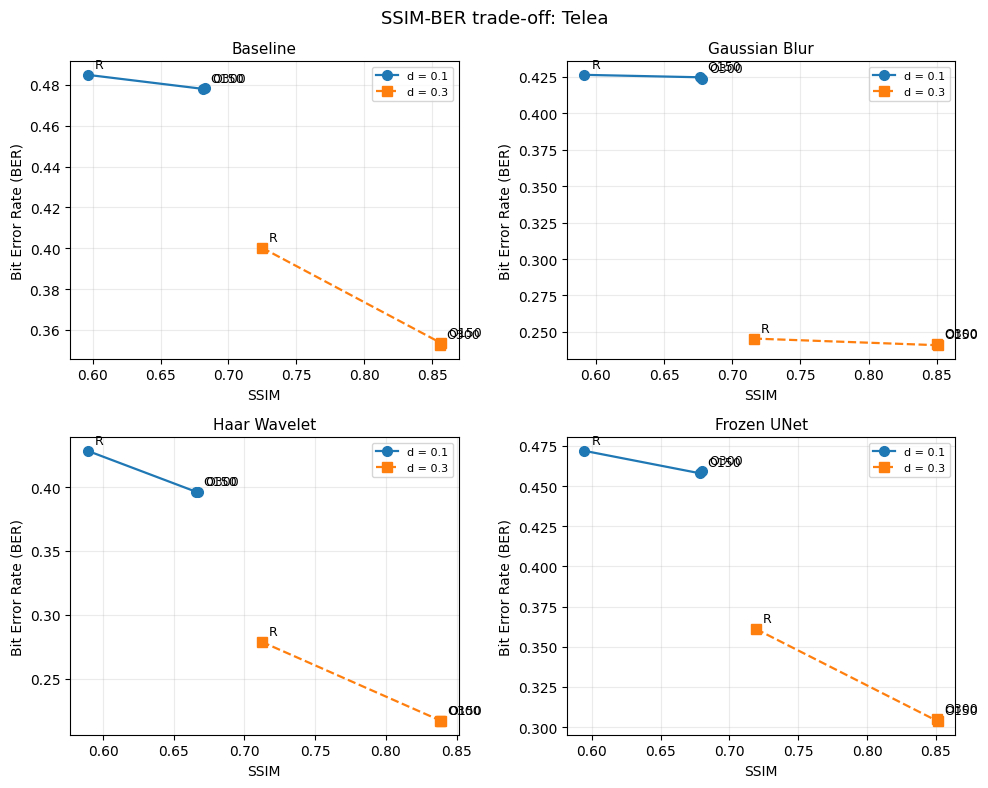

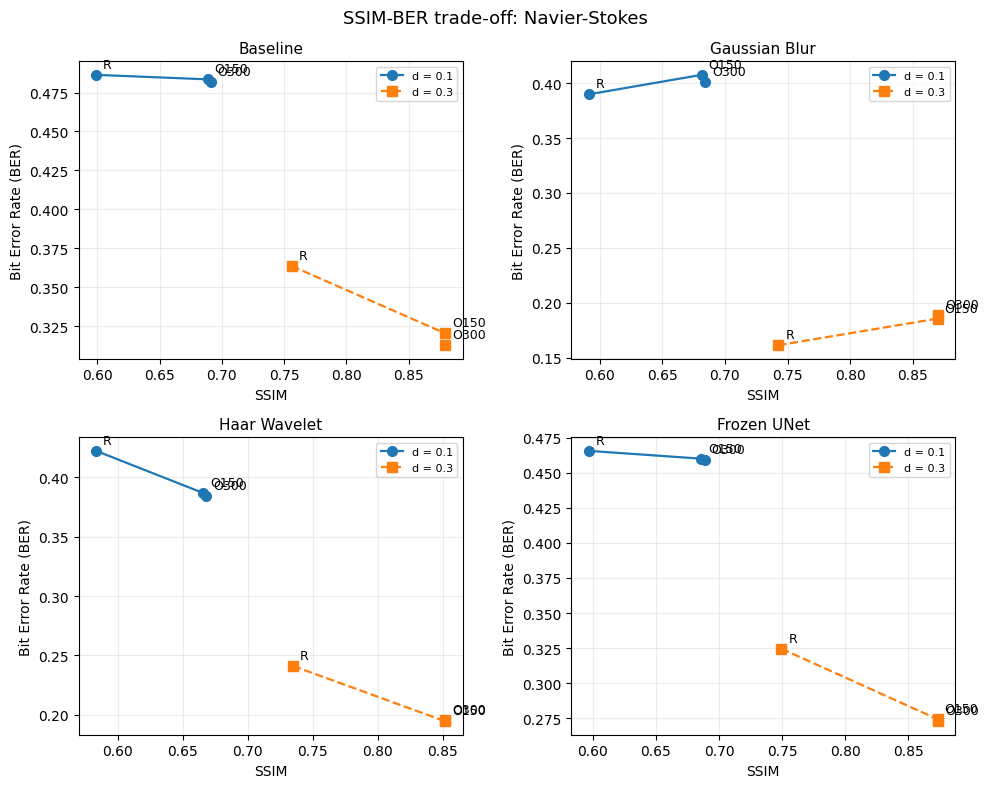

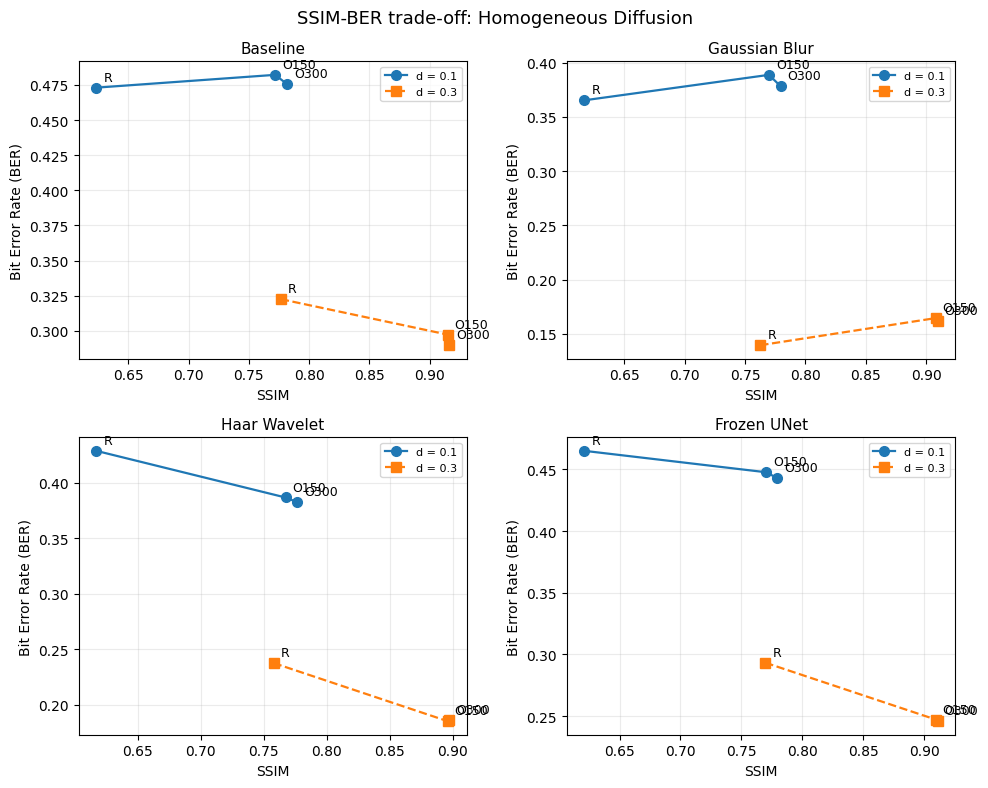

In [39]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Load data
# ============================================================

csv_path = Path("/home/keen/HiDDeN/output/csv/sparse_mask_results.csv")

df = pd.read_csv(csv_path)

print(df.columns.tolist())
print(df["model"].unique())
print(df["attack"].unique())
print(df["mask_type"].unique())


# ============================================================
# 2. Rename mask configurations
# ============================================================

mask_name_map = {
    "Random": "R",
    "Optimized_d150_n100": "O150",
    "Optimized_d300_n200": "O300",
}

df["mask_label"] = df["mask_type"].map(mask_name_map)

mask_order = ["R", "O150", "O300"]

df["mask_label"] = pd.Categorical(
    df["mask_label"],
    categories=mask_order,
    ordered=True,
)


# ============================================================
# 3. Plotting order
# ============================================================

model_order = [
    "Baseline",
    "Gaussian Blur",
    "Haar Wavelet",
    "Frozen UNet",
]

attack_order = [
    "mean",
    "telea",
    "navier",
    "diffusion",
]

attack_titles = {
    "mean": "Mean Fill",
    "telea": "Telea",
    "navier": "Navier-Stokes",
    "diffusion": "Homogeneous Diffusion",
}

density_order = [0.1, 0.3]

density_styles = {
    0.1: {
        "marker": "o",
        "linestyle": "-",
    },
    0.3: {
        "marker": "s",
        "linestyle": "--",
    },
}


# ============================================================
# 4. One figure per inpainting operator
#
# Each figure:
#
#   Baseline       Gaussian Blur
#   Haar Wavelet   Frozen U-Net
#
# No averaging over models.
# ============================================================

for attack in attack_order:

    attack_df = df[
        df["attack"] == attack
    ].copy()

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10, 8),
    )

    axes = axes.flatten()

    for ax, model in zip(axes, model_order):

        model_df = attack_df[
            attack_df["model"] == model
        ]

        for density in density_order:

            current = (
                model_df[
                    model_df["density"] == density
                ]
                .sort_values("mask_label")
            )

            style = density_styles[density]

            ax.plot(
                current["SSIM"],
                current["BER"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=1.6,
                markersize=7,
                label=f"d = {density}",
            )

            # Labels: R, O150, O300
            for _, row in current.iterrows():

                ax.annotate(
                    row["mask_label"],
                    (
                        row["SSIM"],
                        row["BER"],
                    ),
                    xytext=(5, 5),
                    textcoords="offset points",
                    fontsize=9,
                )

        ax.set_title(
            model,
            fontsize=11,
        )

        ax.set_xlabel(
            "SSIM"
        )

        ax.set_ylabel(
            "Bit Error Rate (BER)"
        )

        ax.grid(
            True,
            alpha=0.25,
        )

        ax.legend(
            fontsize=8,
        )

    fig.suptitle(
        f"SSIM-BER trade-off: {attack_titles[attack]}",
        fontsize=13,
    )

    plt.tight_layout()

    output_name = (
        f"sparse_tradeoff_ssim_{attack}.png"
    )

    plt.savefig(
        output_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()